# Multifact Modelling and Visualisation Notebook

This notebook is designed to be run from top to bottom. Tables are calculated from `xfacta_demo_results.csv`. Each figure is generated in its own code cell, so the code for a chart appears immediately above that chart's output.


## Run commands

After downloading the dataset and configuring `.env`, commands like these can be used to produce real model outputs.


In [1]:
DATA_DIR = r"C:\path\to\XFacta_dataset"

commands = [
    f"python Predict.py --llm_name openai/gpt-4o --data_path {DATA_DIR} --reasoning_approach cot_prompt_evidence --dataset_split test --include_evidences 1 3 5 --top_k_evidence 5 --filter_untrusted --evidence_cache",
    f"python Predict.py --llm_name openai/gpt-4o --data_path {DATA_DIR} --reasoning_approach prompt_ensembles_evidence --dataset_split test --include_evidences 1 3 5 --top_k_evidence 5 --filter_untrusted --evidence_cache",
    f"python Predict.py --llm_name openai/gpt-4o --data_path {DATA_DIR} --reasoning_approach multi_step --dataset_split test --include_evidences 1 3 --top_k_evidence 5 --filter_untrusted --evidence_cache",
]

for command in commands:
    print(command)


python Predict.py --llm_name openai/gpt-4o --data_path C:\path\to\XFacta_dataset --reasoning_approach cot_prompt_evidence --dataset_split test --include_evidences 1 3 5 --top_k_evidence 5 --filter_untrusted --evidence_cache
python Predict.py --llm_name openai/gpt-4o --data_path C:\path\to\XFacta_dataset --reasoning_approach prompt_ensembles_evidence --dataset_split test --include_evidences 1 3 5 --top_k_evidence 5 --filter_untrusted --evidence_cache
python Predict.py --llm_name openai/gpt-4o --data_path C:\path\to\XFacta_dataset --reasoning_approach multi_step --dataset_split test --include_evidences 1 3 --top_k_evidence 5 --filter_untrusted --evidence_cache


## Setup and data loading|


In [2]:
from pathlib import Path
import sys
import subprocess

def ensure_package(package_name):
    try:
        __import__(package_name)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])

ensure_package("pandas")
ensure_package("matplotlib")
ensure_package("openpyxl")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display, Markdown
except ImportError:
    def display(obj):
        print(obj)
    class Markdown(str):
        pass

RESULTS_CSV = Path("xfacta_demo_results.csv")
CHART_DIR = Path("charts")
PDF_DIR = Path("charts_pdf")
TABLE_DIR = Path("tables")

for folder in [CHART_DIR, PDF_DIR, TABLE_DIR]:
    folder.mkdir(exist_ok=True)

df = pd.read_csv(RESULTS_CSV)

LABEL_COLUMNS = ["label", "cot_prediction", "ensemble_prediction", "multi_step_prediction"]
for col in LABEL_COLUMNS:
    df[col] = df[col].map(lambda x: "True" if str(x).lower() == "true" else "False")

display(df.head())


,id,label,topic,text_length_words,image_count,evidence1_image_text,evidence3_caption_text,evidence5_web_text,evidence7_question_text,evidence_total,difficulty,failure_mode,cot_prediction,cot_confidence,ensemble_prediction,ensemble_confidence,multi_step_prediction,multi_step_confidence
0,demo_001,False,Conflict,34,3,1,3,3,1,8,0.747742,image-caption mismatch,True,0.625,False,0.801,False,0.847
1,demo_002,True,Disaster,26,2,2,1,2,1,6,0.261255,ambiguous context,True,0.758,True,0.775,True,0.866
2,demo_003,False,Economy,57,1,2,4,2,1,9,0.123763,missing reliable evidence,False,0.799,False,0.815,False,0.799
3,demo_004,True,Celebrity,36,1,3,2,6,1,12,0.100445,entity/date mismatch,True,0.767,True,0.838,True,0.816
4,demo_005,False,Election,32,2,3,2,2,0,7,0.611412,missing reliable evidence,False,0.830,False,0.774,False,0.896


## Metrics and tables


In [3]:
def evaluate_model(df, pred_col, model_name):
    y_true_fake = df["label"].eq("False")
    y_pred_fake = df[pred_col].eq("False")
    tp = int((y_true_fake & y_pred_fake).sum())
    fp = int((~y_true_fake & y_pred_fake).sum())
    fn = int((y_true_fake & ~y_pred_fake).sum())
    tn = int((~y_true_fake & ~y_pred_fake).sum())
    accuracy = (tp + tn) / len(df)
    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
    return {
        "Model": model_name,
        "Accuracy": round(accuracy, 3),
        "Precision": round(precision, 3),
        "Recall": round(recall, 3),
        "F1": round(f1, 3),
        "TP_fake": tp,
        "FP_fake": fp,
        "FN_fake": fn,
        "TN_true": tn,
    }

metrics = pd.DataFrame([
    evaluate_model(df, "cot_prediction", "CoT evidence"),
    evaluate_model(df, "ensemble_prediction", "Prompt ensemble"),
    evaluate_model(df, "multi_step_prediction", "Multi-step"),
])

display(metrics)
metrics.to_csv(TABLE_DIR / "model_metrics.csv", index=False)


,Model,Accuracy,Precision,Recall,F1,TP_fake,FP_fake,FN_fake,TN_true
0,CoT evidence,0.778,0.794,0.750,0.771,27,7,9,29
1,Prompt ensemble,0.819,0.829,0.806,0.817,29,6,7,30
2,Multi-step,0.847,0.838,0.861,0.849,31,6,5,30


In [4]:
model_rationale = pd.DataFrame([
    {"Model": "CoT evidence", "Rationale": "Interpretable baseline using one chain-of-thought evidence prompt.", "Evidence inputs": "Evidence 1, 3, 5"},
    {"Model": "Prompt ensemble", "Rationale": "Tests whether multiple prompt variants reduce wording sensitivity.", "Evidence inputs": "Evidence 1, 3, 5"},
    {"Model": "Multi-step", "Rationale": "Separates caption truthfulness, image misuse, and final judgement.", "Evidence inputs": "Evidence 1, 3"},
])

dataset_summary = pd.DataFrame([
    {"Item": "Total posts", "Value": len(df)},
    {"Item": "Authentic posts", "Value": int((df["label"] == "True").sum())},
    {"Item": "Misinformation posts", "Value": int((df["label"] == "False").sum())},
    {"Item": "Mean caption length", "Value": round(df["text_length_words"].mean(), 2)},
    {"Item": "Mean images per post", "Value": round(df["image_count"].mean(), 2)},
    {"Item": "Mean evidence items", "Value": round(df["evidence_total"].mean(), 2)},
])

topic_accuracy = (
    df.assign(
        **{
            "CoT evidence": df["cot_prediction"].eq(df["label"]),
            "Prompt ensemble": df["ensemble_prediction"].eq(df["label"]),
            "Multi-step": df["multi_step_prediction"].eq(df["label"]),
        }
    )
    .groupby("topic")[["CoT evidence", "Prompt ensemble", "Multi-step"]]
    .mean()
    .round(3)
    .reset_index()
    .rename(columns={"topic": "Topic"})
)

def confusion_matrix_for(df, pred_col):
    actual_true = df["label"].eq("True")
    pred_true = df[pred_col].eq("True")
    return np.array([
        [int((actual_true & pred_true).sum()), int((actual_true & ~pred_true).sum())],
        [int((~actual_true & pred_true).sum()), int((~actual_true & ~pred_true).sum())],
    ])

confusion_rows = []
for pred_col, model in [
    ("cot_prediction", "CoT evidence"),
    ("ensemble_prediction", "Prompt ensemble"),
    ("multi_step_prediction", "Multi-step"),
]:
    matrix = confusion_matrix_for(df, pred_col)
    confusion_rows.extend([
        {"Model": model, "Actual": "Authentic", "Predicted authentic": int(matrix[0, 0]), "Predicted misinformation": int(matrix[0, 1])},
        {"Model": model, "Actual": "Misinformation", "Predicted authentic": int(matrix[1, 0]), "Predicted misinformation": int(matrix[1, 1])},
    ])
confusion_matrices = pd.DataFrame(confusion_rows)

error_type_counts = pd.DataFrame({
    "CoT evidence": df[df["cot_prediction"] != df["label"]]["failure_mode"].value_counts(),
    "Prompt ensemble": df[df["ensemble_prediction"] != df["label"]]["failure_mode"].value_counts(),
    "Multi-step": df[df["multi_step_prediction"] != df["label"]]["failure_mode"].value_counts(),
}).fillna(0).astype(int).reset_index().rename(columns={"index": "Failure mode"})

evidence_coverage = pd.DataFrame([
    {"Evidence source": "Image-search text", "Coverage": round((df["evidence1_image_text"] > 0).mean(), 3)},
    {"Evidence source": "Caption-search text", "Coverage": round((df["evidence3_caption_text"] > 0).mean(), 3)},
    {"Evidence source": "Web-text retrieval", "Coverage": round((df["evidence5_web_text"] > 0).mean(), 3)},
    {"Evidence source": "Generated-question evidence", "Coverage": round((df["evidence7_question_text"] > 0).mean(), 3)},
])

tables = {
    "model_rationale": model_rationale,
    "model_metrics": metrics,
    "dataset_summary": dataset_summary,
    "topic_accuracy": topic_accuracy,
    "confusion_matrices": confusion_matrices,
    "error_type_counts": error_type_counts,
    "evidence_coverage": evidence_coverage,
}

for name, table in tables.items():
    display(Markdown(f"### {name.replace('_', ' ').title()}"))
    display(table)
    table.to_csv(TABLE_DIR / f"{name}.csv", index=False)

with pd.ExcelWriter(TABLE_DIR / "xfacta_analysis_tables.xlsx", engine="openpyxl") as writer:
    for name, table in tables.items():
        table.to_excel(writer, sheet_name=name[:31], index=False)


### Model Rationale

,Model,Rationale,Evidence inputs
0,CoT evidence,Interpretable baseline using one chain-of-thou...,"Evidence 1, 3, 5"
1,Prompt ensemble,Tests whether multiple prompt variants reduce ...,"Evidence 1, 3, 5"
2,Multi-step,"Separates caption truthfulness, image misuse, ...","Evidence 1, 3"


### Model Metrics

,Model,Accuracy,Precision,Recall,F1,TP_fake,FP_fake,FN_fake,TN_true
0,CoT evidence,0.778,0.794,0.750,0.771,27,7,9,29
1,Prompt ensemble,0.819,0.829,0.806,0.817,29,6,7,30
2,Multi-step,0.847,0.838,0.861,0.849,31,6,5,30


### Dataset Summary

...

,Model,Actual,Predicted authentic,Predicted misinformation
0,CoT evidence,Authentic,29,7
1,CoT evidence,Misinformation,9,27
2,Prompt ensemble,Authentic,30,6
3,Prompt ensemble,Misinformation,7,29
4,Multi-step,Authentic,30,6
5,Multi-step,Misinformation,5,31


### Error Type Counts

,Failure mode,CoT evidence,Prompt ensemble,Multi-step
0,ambiguous context,3,2,2
1,entity/date mismatch,5,4,3
2,image-caption mismatch,3,2,2
3,missing reliable evidence,3,3,3
4,satire or rhetorical framing,2,2,1


### Evidence Coverage

,Evidence source,Coverage
0,Image-search text,0.931
1,Caption-search text,0.875
2,Web-text retrieval,0.806
3,Generated-question evidence,0.778


## Shared plotting style

This cell only defines the shared visual style and helper functions. The actual plotting code for each figure appears in the individual figure cells below.


In [6]:
SCI = {
    "authentic": "#2F6F9F",
    "misinfo": "#C94C4C",
    "cot": "#2F6F9F",
    "ensemble": "#D89C27",
    "multi": "#4F9D69",
    "purple": "#7A6BA8",
    "gray": "#5B6770",
    "light_grid": "#D9DEE7",
    "ink": "#1D2733",
}

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 13,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "axes.titleweight": "bold",
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 11.5,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": SCI["ink"],
    "axes.linewidth": 1.0,
    "savefig.dpi": 300,
})

def polish_axes(ax, grid_axis="y"):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(True, axis=grid_axis, color=SCI["light_grid"], linewidth=0.8, alpha=0.75)
    ax.set_axisbelow(True)

def save_and_show(fig, filename, caption):
    png_path = CHART_DIR / filename
    pdf_path = PDF_DIR / filename.replace(".png", ".pdf")
    fig.savefig(png_path, dpi=300, bbox_inches="tight", pad_inches=0.08)
    fig.savefig(pdf_path, bbox_inches="tight", pad_inches=0.08)
    display(Markdown(f"**{caption}**"))
    display(fig)
    plt.close(fig)

def autolabel(ax, bars, fmt="{:.0f}"):
    top = ax.get_ylim()[1]
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + top*0.015, fmt.format(h), ha="center", va="bottom", fontsize=11)


### Figure 1. Class distribution of the evaluation split


**Figure 1. Class distribution of the evaluation split.**

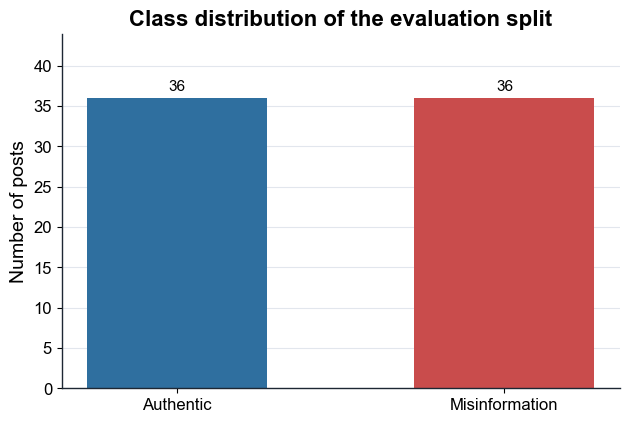

In [7]:
counts = df["label"].map({"True": "Authentic", "False": "Misinformation"}).value_counts().reindex(["Authentic", "Misinformation"])

fig, ax = plt.subplots(figsize=(7.2, 4.6))
bars = ax.bar(counts.index, counts.values, color=[SCI["authentic"], SCI["misinfo"]], width=0.55)
autolabel(ax, bars)

ax.set_title("Class distribution of the evaluation split")
ax.set_ylabel("Number of posts")
ax.set_ylim(0, max(counts.values) * 1.22)
polish_axes(ax)

save_and_show(fig, "01_class_distribution.png", "Figure 1. Class distribution of the evaluation split.")


### Figure 2. Evidence coverage by retrieval source


**Figure 2. Evidence coverage by retrieval source.**

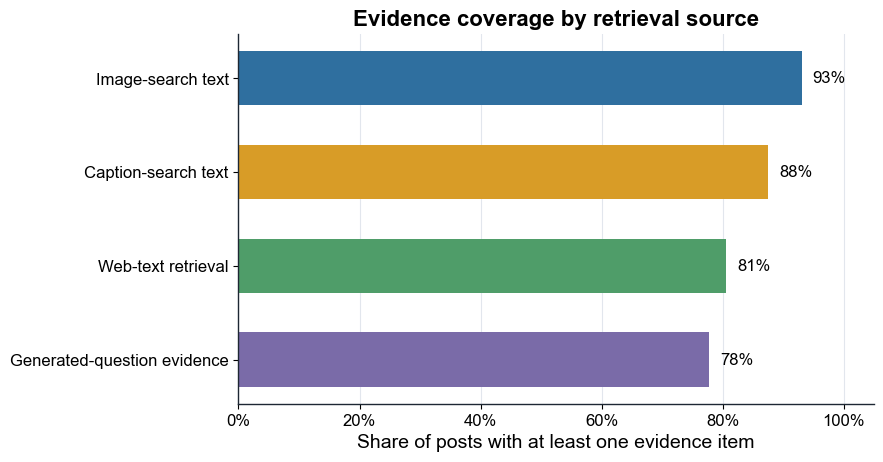

In [8]:
coverage = pd.Series({
    "Image-search text": (df["evidence1_image_text"] > 0).mean(),
    "Caption-search text": (df["evidence3_caption_text"] > 0).mean(),
    "Web-text retrieval": (df["evidence5_web_text"] > 0).mean(),
    "Generated-question evidence": (df["evidence7_question_text"] > 0).mean(),
}).sort_values()

fig, ax = plt.subplots(figsize=(8.2, 4.8))
bars = ax.barh(coverage.index, coverage.values, color=[SCI["purple"], SCI["multi"], SCI["ensemble"], SCI["cot"]], height=0.58)

ax.set_title("Evidence coverage by retrieval source")
ax.set_xlabel("Share of posts with at least one evidence item")
ax.set_xlim(0, 1.05)
ax.set_xticks(np.linspace(0, 1, 6), [f"{int(x*100)}%" for x in np.linspace(0, 1, 6)])

for bar, value in zip(bars, coverage.values):
    ax.text(value + 0.018, bar.get_y() + bar.get_height()/2, f"{value:.0%}", va="center", fontsize=12)

polish_axes(ax, grid_axis="x")
save_and_show(fig, "04_evidence_coverage.png", "Figure 2. Evidence coverage by retrieval source.")


### Figure 3. Model performance across four classification metrics


**Figure 3. Model performance across four classification metrics.**

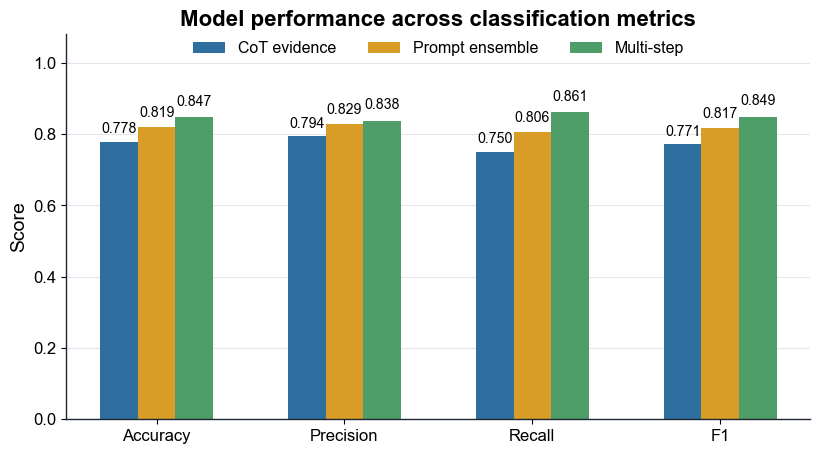

In [9]:
metric_names = ["Accuracy", "Precision", "Recall", "F1"]
x = np.arange(len(metric_names))
width = 0.20
colors = {"CoT evidence": SCI["cot"], "Prompt ensemble": SCI["ensemble"], "Multi-step": SCI["multi"]}

fig, ax = plt.subplots(figsize=(9.6, 5.0))
for i, model in enumerate(metrics["Model"]):
    values = metrics.loc[metrics["Model"] == model, metric_names].iloc[0].astype(float).values
    bars = ax.bar(x + (i-1)*width, values, width=width, label=model, color=colors[model])
    for bar, value in zip(bars, values):
        ax.text(bar.get_x()+bar.get_width()/2, value + 0.016 + i*0.004, f"{value:.3f}", ha="center", va="bottom", fontsize=10.2)

ax.set_title("Model performance across classification metrics")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.08)
ax.set_xticks(x, metric_names)
ax.legend(frameon=False, ncol=3, loc="upper center", bbox_to_anchor=(0.5, 1.02))
polish_axes(ax)

save_and_show(fig, "05_model_metrics.png", "Figure 3. Model performance across four classification metrics.")


### Figure 4. Accuracy by topic


**Figure 4. Accuracy by topic.**

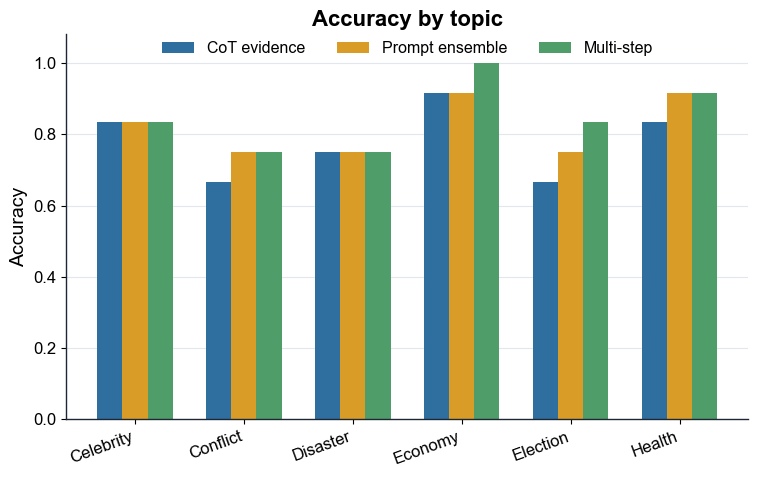

In [10]:
models = [
    ("cot_prediction", "CoT evidence", SCI["cot"]),
    ("ensemble_prediction", "Prompt ensemble", SCI["ensemble"]),
    ("multi_step_prediction", "Multi-step", SCI["multi"]),
]
topics = sorted(df["topic"].unique())
x = np.arange(len(topics))
width = 0.23

fig, ax = plt.subplots(figsize=(8.8, 5.0))
for i, (col, label, color) in enumerate(models):
    values = [(df.loc[df["topic"] == topic, col] == df.loc[df["topic"] == topic, "label"]).mean() for topic in topics]
    ax.bar(x + (i-1)*width, values, width=width, color=color, label=label)

ax.set_title("Accuracy by topic")
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1.08)
ax.set_xticks(x, topics, rotation=20, ha="right")
ax.legend(frameon=False, ncol=3, loc="upper center", bbox_to_anchor=(0.5, 1.02))
polish_axes(ax)

save_and_show(fig, "08_topic_accuracy.png", "Figure 4. Accuracy by topic.")


### Figure 5. Confusion matrix for the best-performing multi-step configuration


**Figure 5. Confusion matrix for the best-performing multi-step configuration.**

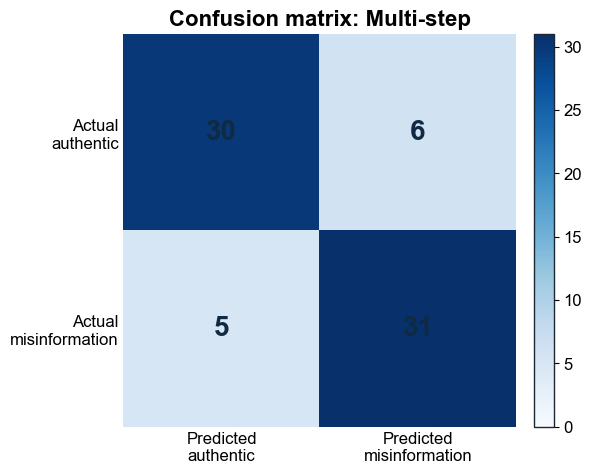

In [11]:
matrix = confusion_matrix_for(df, "multi_step_prediction")

fig, ax = plt.subplots(figsize=(5.8, 5.1))
im = ax.imshow(matrix, cmap="Blues", vmin=0, vmax=max(matrix.max(), 1))

ax.set_title("Confusion matrix: Multi-step")
ax.set_xticks([0, 1], labels=["Predicted\nauthentic", "Predicted\nmisinformation"])
ax.set_yticks([0, 1], labels=["Actual\nauthentic", "Actual\nmisinformation"])

for i in range(2):
    for j in range(2):
        ax.text(j, i, str(int(matrix[i, j])), ha="center", va="center", fontsize=20, fontweight="bold", color="#102A43")

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(length=0)

save_and_show(fig, "07_confusion_multi_step.png", "Figure 5. Confusion matrix for the best-performing multi-step configuration.")


### Figure 6. Distribution of misclassification types across models


**Figure 6. Distribution of misclassification types across models.**

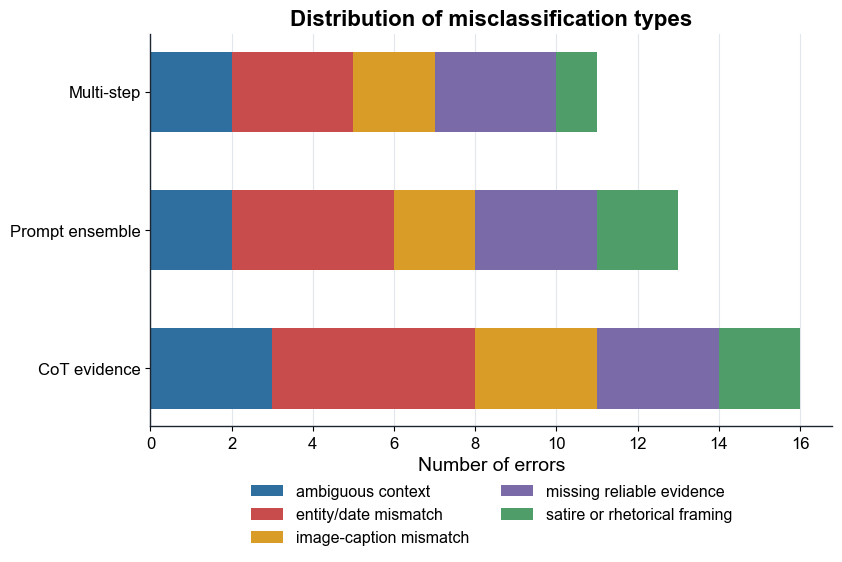

In [12]:
counts = pd.DataFrame({
    "CoT evidence": df[df["cot_prediction"] != df["label"]]["failure_mode"].value_counts(),
    "Prompt ensemble": df[df["ensemble_prediction"] != df["label"]]["failure_mode"].value_counts(),
    "Multi-step": df[df["multi_step_prediction"] != df["label"]]["failure_mode"].value_counts(),
}).fillna(0).astype(int).T

fig, ax = plt.subplots(figsize=(8.8, 5.1))
left = np.zeros(len(counts.index))
palette = [SCI["cot"], SCI["misinfo"], SCI["ensemble"], SCI["purple"], SCI["multi"]]

for failure_mode, color in zip(counts.columns, palette):
    values = counts[failure_mode].values
    ax.barh(counts.index, values, left=left, color=color, height=0.58, label=failure_mode)
    left += values

ax.set_title("Distribution of misclassification types")
ax.set_xlabel("Number of errors")
ax.legend(frameon=False, loc="lower center", bbox_to_anchor=(0.5, -0.34), ncol=2)
polish_axes(ax, grid_axis="x")

save_and_show(fig, "09_error_types.png", "Figure 6. Distribution of misclassification types across models.")


### Figure 7. Accuracy under evidence-rich and evidence-poor conditions


**Figure 7. Accuracy under evidence-rich and evidence-poor conditions.**

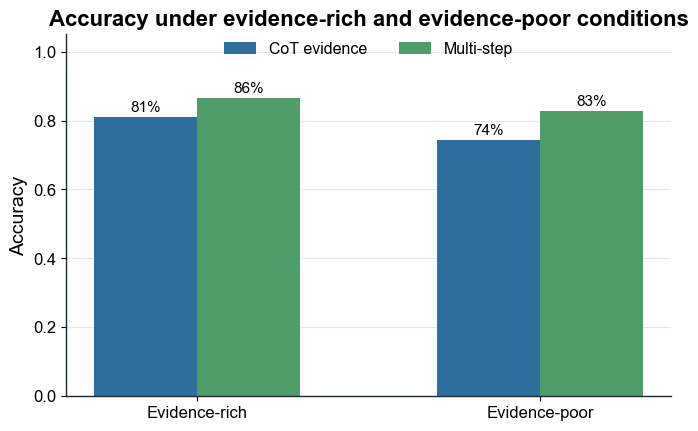

In [13]:
work = df.copy()
work["Evidence availability"] = np.where(work["evidence_total"] >= work["evidence_total"].median(), "Evidence-rich", "Evidence-poor")
groups = ["Evidence-rich", "Evidence-poor"]

cot_values = [(work.loc[work["Evidence availability"] == group, "cot_prediction"] == work.loc[work["Evidence availability"] == group, "label"]).mean() for group in groups]
multi_values = [(work.loc[work["Evidence availability"] == group, "multi_step_prediction"] == work.loc[work["Evidence availability"] == group, "label"]).mean() for group in groups]

x = np.arange(len(groups))
width = 0.30
fig, ax = plt.subplots(figsize=(7.8, 4.7))
b1 = ax.bar(x - width/2, cot_values, width=width, color=SCI["cot"], label="CoT evidence")
b2 = ax.bar(x + width/2, multi_values, width=width, color=SCI["multi"], label="Multi-step")

for bars in [b1, b2]:
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.015, f"{bar.get_height():.0%}", ha="center", fontsize=11)

ax.set_title("Accuracy under evidence-rich and evidence-poor conditions")
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1.05)
ax.set_xticks(x, groups)
ax.legend(frameon=False, ncol=2, loc="upper center", bbox_to_anchor=(0.5, 1.02))
polish_axes(ax)

save_and_show(fig, "12_evidence_impact.png", "Figure 7. Accuracy under evidence-rich and evidence-poor conditions.")


### Additional Figure A. Topic composition by ground-truth label


**Additional Figure A. Topic composition by ground-truth label.**

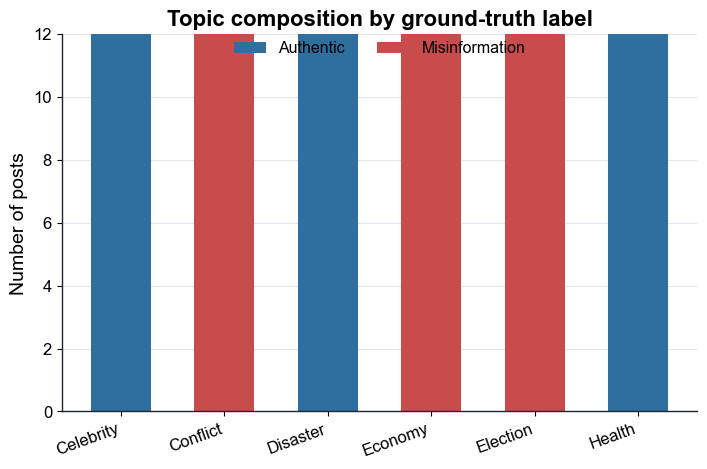

In [14]:
pivot = (
    df.assign(label_name=df["label"].map({"True": "Authentic", "False": "Misinformation"}))
    .pivot_table(index="topic", columns="label_name", values="id", aggfunc="count", fill_value=0)
    .sort_index()
)

x = np.arange(len(pivot.index))
fig, ax = plt.subplots(figsize=(8.2, 4.9))
authentic = pivot.get("Authentic", pd.Series(0, index=pivot.index))
misinfo = pivot.get("Misinformation", pd.Series(0, index=pivot.index))

ax.bar(x, authentic, color=SCI["authentic"], width=0.58, label="Authentic")
ax.bar(x, misinfo, bottom=authentic, color=SCI["misinfo"], width=0.58, label="Misinformation")

ax.set_title("Topic composition by ground-truth label")
ax.set_ylabel("Number of posts")
ax.set_xticks(x, pivot.index, rotation=20, ha="right")
ax.legend(frameon=False, ncol=2, loc="upper center", bbox_to_anchor=(0.5, 1.02))
polish_axes(ax)

save_and_show(fig, "02_topic_distribution.png", "Additional Figure A. Topic composition by ground-truth label.")


### Additional Figure B. Caption length distribution


**Additional Figure B. Caption length distribution.**

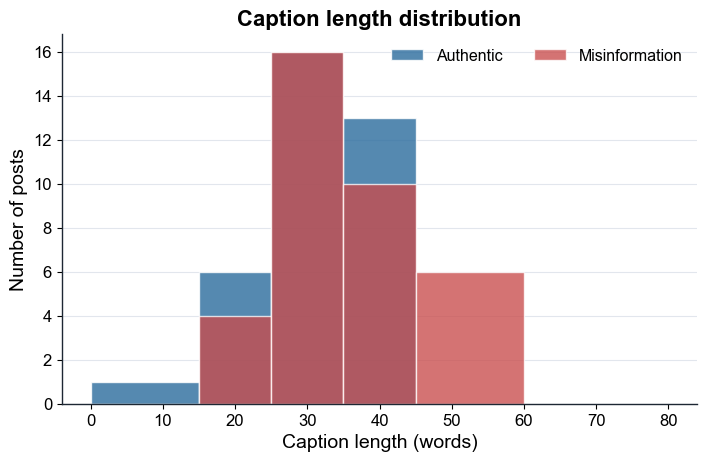

In [15]:
fig, ax = plt.subplots(figsize=(8.2, 4.8))
bins = [0, 15, 25, 35, 45, 60, 80]

ax.hist(df.loc[df["label"] == "True", "text_length_words"], bins=bins, color=SCI["authentic"], alpha=0.82, label="Authentic", edgecolor="white")
ax.hist(df.loc[df["label"] == "False", "text_length_words"], bins=bins, color=SCI["misinfo"], alpha=0.78, label="Misinformation", edgecolor="white")

ax.set_title("Caption length distribution")
ax.set_xlabel("Caption length (words)")
ax.set_ylabel("Number of posts")
ax.legend(frameon=False, ncol=2)
polish_axes(ax)

save_and_show(fig, "03_caption_length_distribution.png", "Additional Figure B. Caption length distribution.")


### Additional Figure C. Confusion matrix for the CoT evidence baseline


**Additional Figure C. Confusion matrix for the CoT evidence baseline.**

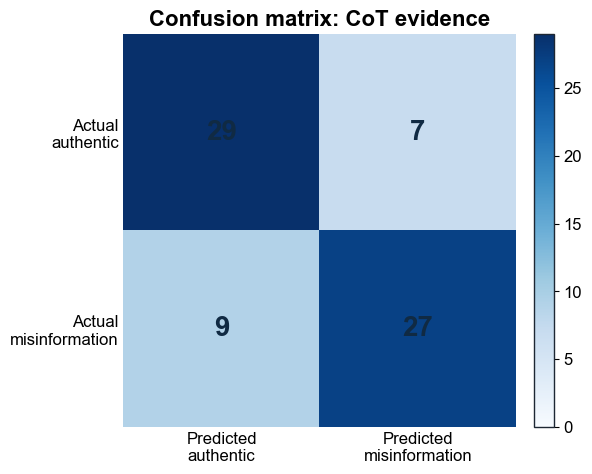

In [16]:
matrix = confusion_matrix_for(df, "cot_prediction")

fig, ax = plt.subplots(figsize=(5.8, 5.1))
im = ax.imshow(matrix, cmap="Blues", vmin=0, vmax=max(matrix.max(), 1))

ax.set_title("Confusion matrix: CoT evidence")
ax.set_xticks([0, 1], labels=["Predicted\nauthentic", "Predicted\nmisinformation"])
ax.set_yticks([0, 1], labels=["Actual\nauthentic", "Actual\nmisinformation"])

for i in range(2):
    for j in range(2):
        ax.text(j, i, str(int(matrix[i, j])), ha="center", va="center", fontsize=20, fontweight="bold", color="#102A43")

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(length=0)

save_and_show(fig, "06_confusion_cot.png", "Additional Figure C. Confusion matrix for the CoT evidence baseline.")


### Additional Figure D. Average confidence for correct and incorrect decisions


**Additional Figure D. Average confidence for correct and incorrect decisions.**

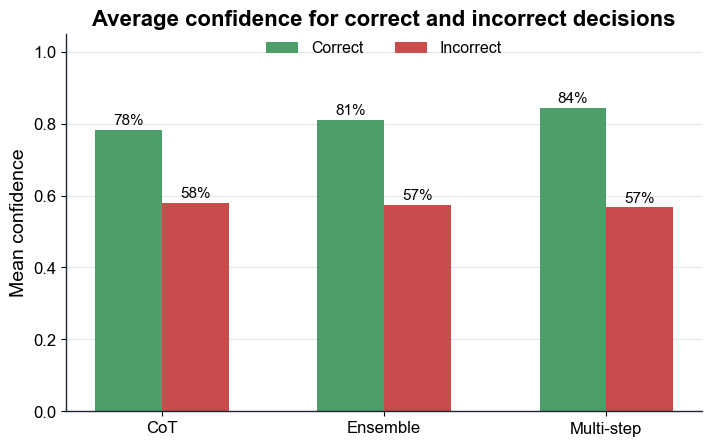

In [17]:
pairs = []
for pred_col, conf_col, model in [
    ("cot_prediction", "cot_confidence", "CoT"),
    ("ensemble_prediction", "ensemble_confidence", "Ensemble"),
    ("multi_step_prediction", "multi_step_confidence", "Multi-step"),
]:
    pairs.append((model, "Correct", df[df[pred_col] == df["label"]][conf_col].mean()))
    pairs.append((model, "Incorrect", df[df[pred_col] != df["label"]][conf_col].mean()))

plot_df = pd.DataFrame(pairs, columns=["Model", "Decision", "Confidence"])

fig, ax = plt.subplots(figsize=(8.2, 4.9))
x = np.arange(plot_df["Model"].nunique())
width = 0.30

for i, (decision, color) in enumerate([("Correct", SCI["multi"]), ("Incorrect", SCI["misinfo"])]):
    values = plot_df[plot_df["Decision"] == decision]["Confidence"].values
    bars = ax.bar(x + (i - 0.5)*width, values, width=width, color=color, label=decision)
    for bar, value in zip(bars, values):
        ax.text(bar.get_x()+bar.get_width()/2, value+0.015, f"{value:.0%}", ha="center", fontsize=11)

ax.set_title("Average confidence for correct and incorrect decisions")
ax.set_ylabel("Mean confidence")
ax.set_ylim(0, 1.05)
ax.set_xticks(x, plot_df["Model"].unique())
ax.legend(frameon=False, ncol=2, loc="upper center", bbox_to_anchor=(0.5, 1.02))
polish_axes(ax)

save_and_show(fig, "10_confidence_correct_wrong.png", "Additional Figure D. Average confidence for correct and incorrect decisions.")


### Additional Figure E. Number of images per post


**Additional Figure E. Number of images per post.**

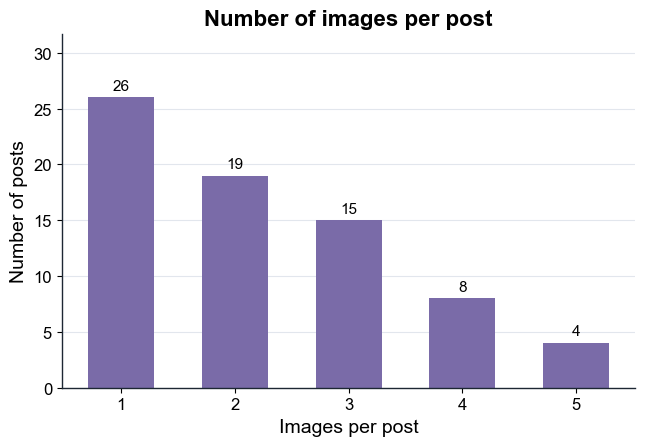

In [18]:
counts = df["image_count"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(7.4, 4.6))
bars = ax.bar(counts.index.astype(str), counts.values, color=SCI["purple"], width=0.58)
autolabel(ax, bars)

ax.set_title("Number of images per post")
ax.set_xlabel("Images per post")
ax.set_ylabel("Number of posts")
ax.set_ylim(0, max(counts.values) * 1.22)
polish_axes(ax)

save_and_show(fig, "11_image_count_distribution.png", "Additional Figure E. Number of images per post.")


## Limitations and failure modes

- The full Multifact workflow depends on external data, cached evidence, and API credentials. This notebook therefore includes a reproducible offline mode.
- Search-based evidence can be stale, incomplete, or polluted by reposts.
- Image-caption mismatch remains difficult because a real image may be paired with a misleading caption.
- Prompt-based MLLM systems can be sensitive to evidence ordering, prompt wording, and top-k retrieval settings.
- Stakeholder use should favour human review for low-confidence or high-impact decisions.
